# 1-D point clouds

## Line Segment

In [61]:
import matplotlib.pyplot as plt
import numpy as np

In [62]:
def line_to_pointcloud(line, num_points=100, jitter=0.0):
    """
    Convert a line segment to a pointcloud with optional noise.
    line: tuple of (start, end)
    jitter: Standard deviation of the Gaussian noise
    """
    start = np.array(line[0])
    end = np.array(line[1])
    
    t = np.linspace(0, 1, num_points)[:, np.newaxis]

    points = (1 - t) * start + t * end + np.random.normal(scale=jitter, size=(num_points, 2))
    

        
    return points 

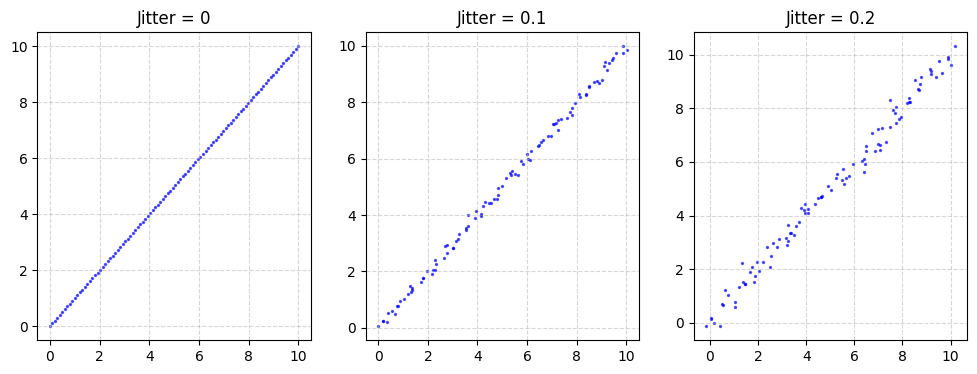

In [63]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))

pt_cld = line_to_pointcloud(((0, 0), (10, 10)), num_points=100, jitter=0.0)
ax[0].scatter(pt_cld[:, 0], pt_cld[:, 1], s=2, alpha=0.6, c='blue')
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_title('Jitter = 0')

pt_cld = line_to_pointcloud(((0, 0), (10, 10)), num_points=100, jitter=0.1)
ax[1].scatter(pt_cld[:, 0], pt_cld[:, 1], s=2, alpha=0.6, c='blue')
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_title('Jitter = 0.1')

pt_cld = line_to_pointcloud(((0, 0), (10, 10)), num_points=100, jitter=0.2)
ax[2].scatter(pt_cld[:, 0], pt_cld[:, 1], s=2, alpha=0.6, c='blue')
ax[2].grid(True, linestyle='--', alpha=0.5)
ax[2].set_title('Jitter = 0.2')

plt.show()

## IPT of Line segment

In [64]:
def generate_directions(n):
    """Generates n regular directions in 2D."""
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.stack((np.cos(angles), np.sin(angles)), axis=1)

def scale_set(data):
    ax = 1 if data.ndim == 3 else 0
    
    centered = data - data.mean(axis=ax, keepdims=True)
    radii = np.linalg.norm(centered, axis=-1, keepdims=True)
    max_radii = np.max(radii, axis=ax, keepdims=True)
    
    return centered / max_radii

def compute_ipt(pt_cld, num_directions=20, num_thresholds=32, radius=1.0):
    """Computes ECT/IPT for a single point cloud."""
    pt_cld = scale_set(pt_cld)
    
    directions = generate_directions(num_directions)
    thresholds = np.linspace(-radius, radius, num_thresholds)

    projections = np.dot(directions, pt_cld.T)

    features = np.sum(projections[:, :, np.newaxis] <= thresholds, axis=1)
    
    return features

In [65]:
pt_cld = line_to_pointcloud(((0, 0), (10, 10)), num_points=100, jitter=0.0)
ipt_line_seg = compute_ipt(pt_cld)

pt_cld = line_to_pointcloud(((0, 0), (10, 10)), num_points=100, jitter=0.1)
ipt_jitter_line_seg = compute_ipt(pt_cld)

pt_cld = line_to_pointcloud(((0, 0), (10, 10)), num_points=100, jitter=0.2)
ipt_jitter2_line_seg = compute_ipt(pt_cld)

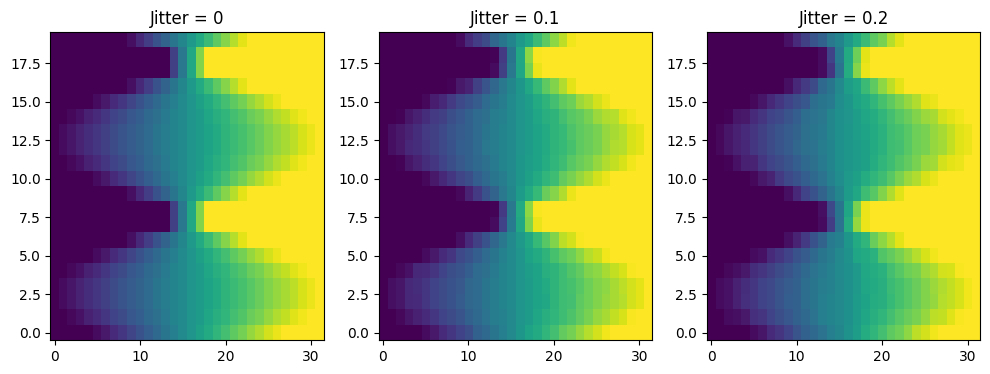

In [66]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))

ax[0].imshow(ipt_line_seg, aspect='auto', origin='lower')
ax[0].set_title('Jitter = 0')

ax[1].imshow(ipt_jitter_line_seg, aspect='auto', origin='lower')
ax[1].set_title('Jitter = 0.1')

ax[2].imshow(ipt_jitter2_line_seg, aspect='auto', origin='lower')
ax[2].set_title('Jitter = 0.2')

plt.show()

Distance Between the two in different metrics.

The metric from the IPT paper(Batein Rieck):
1. For each direction v_i, calculate the L2-norm of the difference between ipt_x[i] and ipt_y[i].
2. Average over all directions.
3. Note: Here we are not normalizing the IPT by number of points in the cloud.

In [67]:
def IPT_metric(ipt_x, ipt_y, n_pts):
    num_directions = ipt_x.shape[0]
    
    # Calculate the sum of L2-norms for each direction
    total_dist = 0
    for i in range(num_directions):
        total_dist += np.linalg.norm(ipt_x[i] - ipt_y[i])
        
    return total_dist / num_directions
print(f"the distance between ipt_line_seg and ipt_jitter_line_seg is {IPT_metric(ipt_line_seg, ipt_jitter_line_seg, 100)}")
print(f"the distance between ipt_line_seg and ipt_jitter2_line_seg is {IPT_metric(ipt_line_seg, ipt_jitter2_line_seg, 100)}")


the distance between ipt_line_seg and ipt_jitter_line_seg is 3.7504455801412355
the distance between ipt_line_seg and ipt_jitter2_line_seg is 5.065378803686353


Metric from ECT stability paper:
1. For each direction v_i, calculate the L2-norm of the difference between ipt_x[i] and ipt_y[i].
2. Find the maximum L2-norm over all directions.
3. Note: Here we are not normalizing the IPT by number of points in the cloud.

In [68]:
def Stability_metric(ipt_x, ipt_y, n_pts):
    num_directions = ipt_x.shape[0]
    
    # Calculate the sum of L2-norms for each direction
    max_dist = 0
    for i in range(num_directions):
        v_i = np.linalg.norm(ipt_x[i] - ipt_y[i])
        if v_i > max_dist:
            max_dist = v_i
        
    return max_dist

print(f"the distance between ipt_line_seg and ipt_jitter_line_seg is {Stability_metric(ipt_line_seg, ipt_jitter_line_seg, 100)}")
print(f"the distance between ipt_line_seg and ipt_jitter2_line_seg is {Stability_metric(ipt_line_seg, ipt_jitter2_line_seg, 100)}")

the distance between ipt_line_seg and ipt_jitter_line_seg is 4.47213595499958
the distance between ipt_line_seg and ipt_jitter2_line_seg is 6.082762530298219


### Ellipse

In [69]:
def ellipse_to_pointcloud(center, axes, angle, num_points=100, jitter=0.0):
    """
    Convert an ellipse to a pointcloud with optional noise.
    center: (x, y)
    axes: (a, b) where a and b are the lengths of the major and minor axes
    angle: rotation angle in degrees
    jitter: Standard deviation of the Gaussian noise
    """
    t = np.linspace(0, 2 * np.pi, num_points)
    
    x = axes[0] * np.cos(t)
    y = axes[1] * np.sin(t)
    
    # Rotate the points by the given angle
    theta = np.radians(angle)
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    
    points = np.dot(R, np.vstack((x, y)))
    
    # Translate to the center and add jitter
    points[0] += center[0] + np.random.normal(scale=jitter, size=num_points)
    points[1] += center[1] + np.random.normal(scale=jitter, size=num_points)
    
    return points.T

Text(0.5, 1.0, 'Jitter = 0')

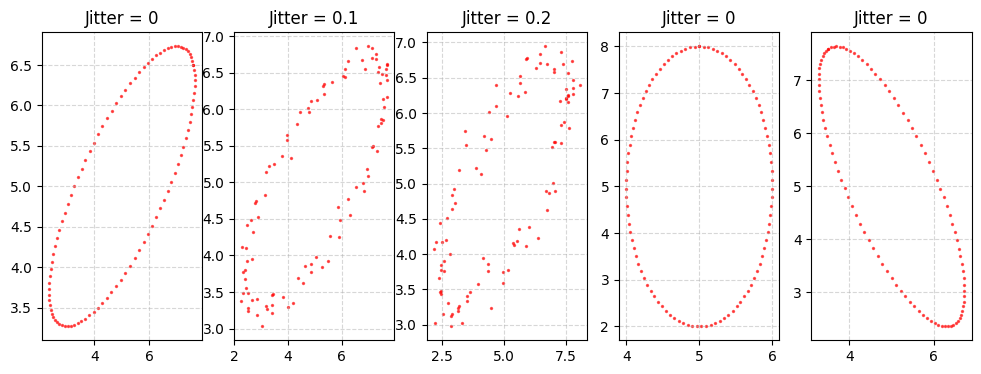

In [70]:
fig, ax = plt.subplots(1,5, figsize=(12, 4))
ellipse_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=30, num_points=100, jitter=0.0)
ax[0].scatter(ellipse_cld[:, 0], ellipse_cld[:, 1], s=2, alpha=0.6, c='red')
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_title('Jitter = 0')   

ellipse_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=30, num_points=100, jitter=0.1)
ax[1].scatter(ellipse_cld[:, 0], ellipse_cld[:, 1], s=2, alpha=0.6, c='red')
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_title('Jitter = 0.1')

ellipse_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=30, num_points=100, jitter=0.2)
ax[2].scatter(ellipse_cld[:, 0], ellipse_cld[:, 1], s=2, alpha=0.6, c='red')
ax[2].grid(True, linestyle='--', alpha=0.5)
ax[2].set_title('Jitter = 0.2')

ellipse_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=90, num_points=100, jitter=0.0)
ax[3].scatter(ellipse_cld[:, 0], ellipse_cld[:, 1], s=2, alpha=0.6, c='red')
ax[3].grid(True, linestyle='--', alpha=0.5)
ax[3].set_title('Jitter = 0')

ellipse_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=120, num_points=100, jitter=0.0)
ax[4].scatter(ellipse_cld[:, 0], ellipse_cld[:, 1], s=2, alpha=0.6, c='red')
ax[4].grid(True, linestyle='--', alpha=0.5)
ax[4].set_title('Jitter = 0')

In [71]:
pt_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=30, num_points=100, jitter=0.0)
ipt_ellipse = compute_ipt(pt_cld)

pt_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=30, num_points=100, jitter=0.1)
ipt_jitter_ellipse = compute_ipt(pt_cld)

pt_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=30, num_points=100, jitter=0.2)
ipt_jitter2_ellipse = compute_ipt(pt_cld)

pt_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=90, num_points=100, jitter=0.0)
ipt_ellipse90 = compute_ipt(pt_cld)

pt_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=120, num_points=100, jitter=0.0)
ipt_ellipse120 = compute_ipt(pt_cld)

print(f"the distance between ipt_ellipse and ipt_jitter_ellipse is {IPT_metric(ipt_ellipse, ipt_jitter_ellipse, 100)}")
print(f"the distance between ipt_ellipse and ipt_jitter2_ellipse is {IPT_metric(ipt_ellipse, ipt_jitter2_ellipse, 100)}")
print(f"the distance between ipt_ellipse and ipt_ellipse90 is {IPT_metric(ipt_ellipse, ipt_ellipse90, 100)}")
print(f"the distance between ipt_ellipse and ipt_ellipse120 is {IPT_metric(ipt_ellipse, ipt_ellipse120, 100)}")
print(f"the distance between ipt_ellipse and ipt_jitter_ellipse is (Stability) {Stability_metric(ipt_ellipse, ipt_jitter_ellipse, 100)}")
print(f"the distance between ipt_ellipse and ipt_jitter2_ellipse is (Stability) {Stability_metric(ipt_ellipse, ipt_jitter2_ellipse, 100)}")
print(f"the distance between ipt_ellipse and ipt_ellipse90 is (Stability) {Stability_metric(ipt_ellipse, ipt_ellipse90, 100)}")
print(f"the distance between ipt_ellipse and ipt_ellipse120 is (Stability) {Stability_metric(ipt_ellipse, ipt_ellipse120, 100)}")

the distance between ipt_ellipse and ipt_jitter_ellipse is 12.105356155462799
the distance between ipt_ellipse and ipt_jitter2_ellipse is 14.875814129713998
the distance between ipt_ellipse and ipt_ellipse90 is 79.42983943084491
the distance between ipt_ellipse and ipt_ellipse120 is 86.0805158677141
the distance between ipt_ellipse and ipt_jitter_ellipse is (Stability) 15.264337522473747
the distance between ipt_ellipse and ipt_jitter2_ellipse is (Stability) 17.804493814764857
the distance between ipt_ellipse and ipt_ellipse90 is (Stability) 118.11435137188029
the distance between ipt_ellipse and ipt_ellipse120 is (Stability) 131.85598204101322


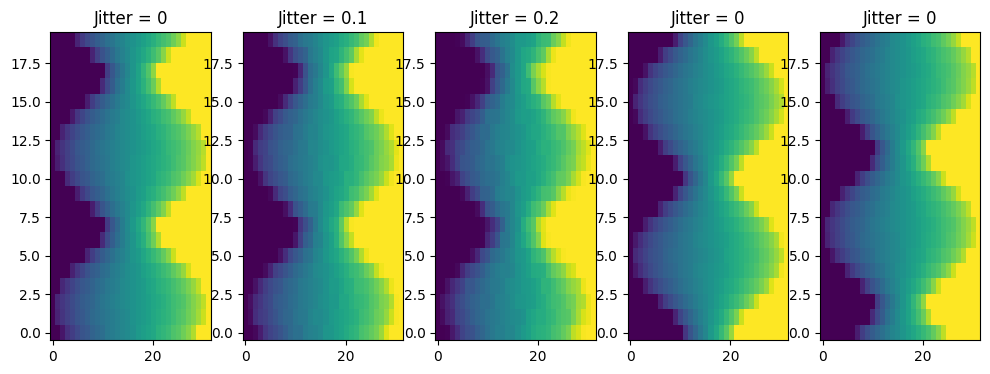

In [72]:
fig, ax = plt.subplots(1,5, figsize=(12, 4))

ax[0].imshow(ipt_ellipse, aspect='auto', origin='lower')
ax[0].set_title('Jitter = 0')
ax[1].imshow(ipt_jitter_ellipse, aspect='auto', origin='lower') 
ax[1].set_title('Jitter = 0.1')
ax[2].imshow(ipt_jitter2_ellipse, aspect='auto', origin='lower')
ax[2].set_title('Jitter = 0.2')
ax[3].imshow(ipt_ellipse90, aspect='auto', origin='lower')
ax[3].set_title('Jitter = 0')
ax[4].imshow(ipt_ellipse120, aspect='auto', origin='lower')
ax[4].set_title('Jitter = 0')
plt.show()

### Sine Curves

In [73]:
def sine_curve_to_pointcloud(amplitude, frequency, length, num_points=100, jitter=0.0):
    """
    Convert a sine curve to a pointcloud with optional noise.
    amplitude: Amplitude of the sine wave
    frequency: Frequency of the sine wave
    length: Length of the curve along the x-axis
    jitter: Standard deviation of the Gaussian noise
    """
    x = np.linspace(0, length, num_points)
    y = amplitude * np.sin(2 * np.pi * frequency * x / length)
    
    points = np.stack((x, y), axis=1) + np.random.normal(scale=jitter, size=(num_points, 2))
    
    return points

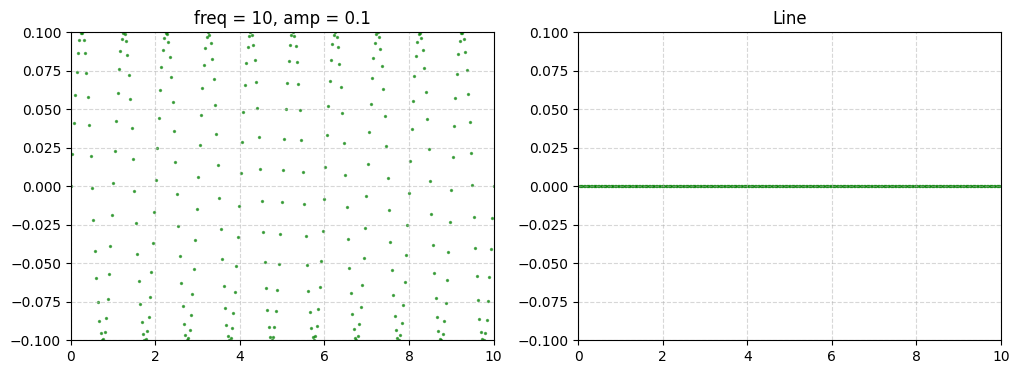

In [79]:
fig, ax = plt.subplots(1,2, figsize=(12, 4))
n = 300
f = 10
amp = 0.1

sine_cld = sine_curve_to_pointcloud(amplitude=amp, frequency=f, length=10, num_points=n, jitter=0.0)
ax[0].scatter(sine_cld[:, 0], sine_cld[:, 1], s=2, alpha=0.6, c='green')
ax[0].grid(True, linestyle='--', alpha=0.5)     
ax[0].set_xlim(0, 10)
ax[0].set_ylim(-0.1, 0.1)  
ax[0].set_title(f'freq = {f}, amp = {amp}')

sine_cld = sine_curve_to_pointcloud(amplitude=1, frequency=0, length=10, num_points=n, jitter=0.0)
ax[1].scatter(sine_cld[:, 0], sine_cld[:, 1], s=2, alpha=0.6, c='green')
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_xlim(0, 10)
ax[1].set_ylim(-0.1, 0.1)  
ax[1].set_title('Line')


plt.show()

In [80]:
sine_cld = sine_curve_to_pointcloud(amplitude=amp, frequency=f, length=10, num_points=n, jitter=0.0)
ipt_sine = compute_ipt(sine_cld, num_directions=20)

sine_cld = sine_curve_to_pointcloud(amplitude=1, frequency=0, length=10, num_points=n, jitter=0.0)
ipt_line = compute_ipt(sine_cld, num_directions=20)

print(f"the distance between ipt_sine and ipt_line is {IPT_metric(ipt_sine, ipt_line, n)}")
print(f"the distance between ipt_sine and ipt_line is (Stability) {Stability_metric(ipt_sine, ipt_line, n)}")

the distance between ipt_sine and ipt_line is 7.21448075268551
the distance between ipt_sine and ipt_line is (Stability) 16.97056274847714


## Difference between IPT of different shapes

In [81]:
line_seg_cld = line_to_pointcloud(((0, 0), (10, 10)), num_points=100, jitter=0.0)
ipt_line_seg = compute_ipt(line_seg_cld)

ellipse_cld = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=30, num_points=100, jitter=0.0)
ipt_ellipse = compute_ipt(ellipse_cld)

circle_cld = ellipse_to_pointcloud(center=(5, 5), axes=(2, 2), angle=0, num_points=100, jitter=0.0)
ipt_circle = compute_ipt(circle_cld)

print(f"the distance between ipt_line_seg and ipt_ellipse is {IPT_metric(ipt_line_seg, ipt_ellipse, 100)}")
print(f"the distance between ipt_line_seg and ipt_ellipse is (Stability) {Stability_metric(ipt_line_seg, ipt_ellipse, 100)}")
print(f"the distance between ipt_line_seg and ipt_circle is {IPT_metric(ipt_line_seg, ipt_circle, 100)}")
print(f"the distance between ipt_line_seg and ipt_circle is (Stability) {Stability_metric(ipt_line_seg, ipt_circle, 100)}")
print(f"the distance between ipt_ellipse and ipt_circle is {IPT_metric(ipt_ellipse, ipt_circle, 100)}")
print(f"the distance between ipt_ellipse and ipt_circle is (Stability) {Stability_metric(ipt_ellipse, ipt_circle, 100)}")

the distance between ipt_line_seg and ipt_ellipse is 50.241111382953974
the distance between ipt_line_seg and ipt_ellipse is (Stability) 105.40398474441088
the distance between ipt_line_seg and ipt_circle is 94.39812271519679
the distance between ipt_line_seg and ipt_circle is (Stability) 167.09578091621583
the distance between ipt_ellipse and ipt_circle is 61.00598248056142
the distance between ipt_ellipse and ipt_circle is (Stability) 130.87780560507576


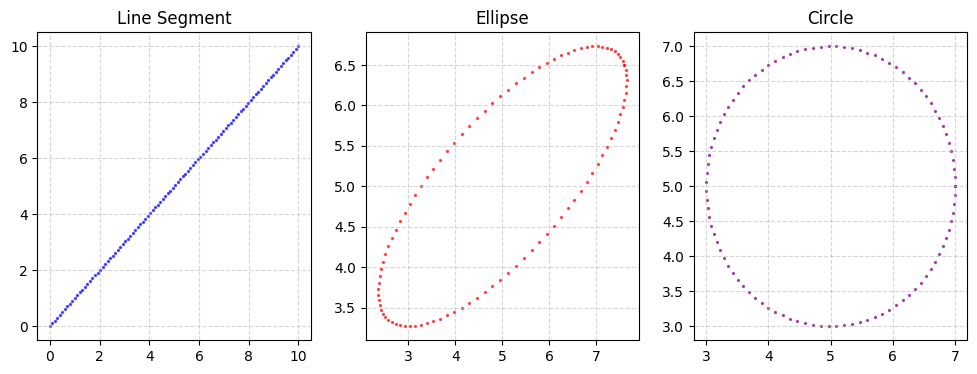

In [83]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
ax[0].scatter(line_seg_cld[:, 0], line_seg_cld[:, 1], s=2, alpha=0.6, c='blue')
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_title('Line Segment')
ax[1].scatter(ellipse_cld[:, 0], ellipse_cld[:, 1], s=2, alpha=0.6, c='red')
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_title('Ellipse')
ax[2].scatter(circle_cld[:, 0], circle_cld[:, 1], s=2, alpha=0.6, c='purple')
ax[2].grid(True, linestyle='--', alpha=0.5)
ax[2].set_title('Circle')

plt.show()

Text(0.5, 1.0, 'Circle')

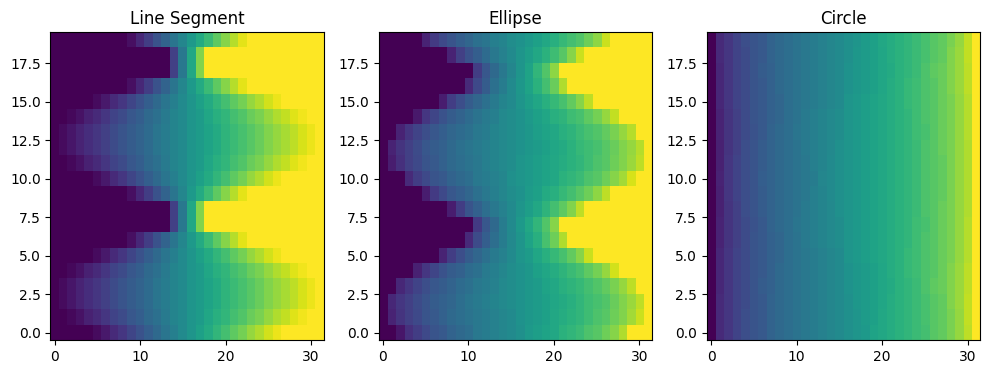

In [82]:
fig, ax = plt.subplots(1,3, figsize=(12, 4))
ax[0].imshow(ipt_line_seg, aspect='auto', origin='lower')
ax[0].set_title('Line Segment')
ax[1].imshow(ipt_ellipse, aspect='auto', origin='lower')
ax[1].set_title('Ellipse')  
ax[2].imshow(ipt_circle, aspect='auto', origin='lower')
ax[2].set_title('Circle')

## Rotated Ellipsies

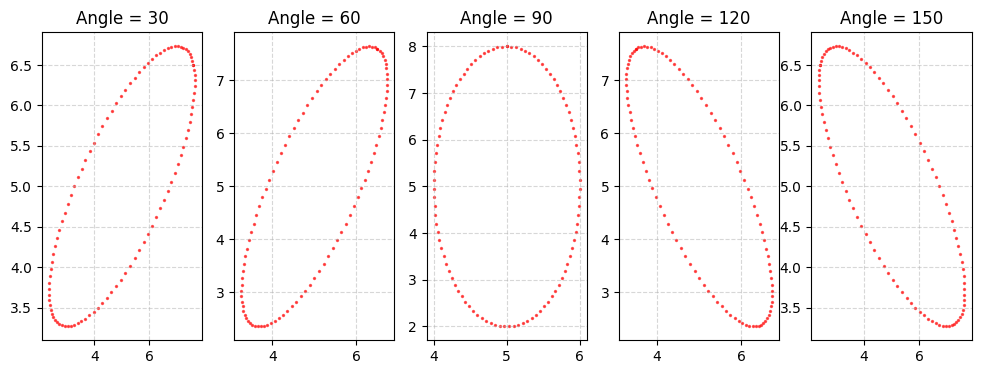

In [89]:
fig, ax = plt.subplots(1,5, figsize=(12, 4))
n = 100

ellipse_30 = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=30, num_points=n, jitter=0.0)
ax[0].scatter(ellipse_30[:, 0], ellipse_30[:, 1], s=2, alpha=0.6, c='red')
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].set_title('Angle = 30')

ellipse_60 = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=60, num_points=n, jitter=0.0)
ax[1].scatter(ellipse_60[:, 0], ellipse_60[:, 1], s=2, alpha=0.6, c='red')  
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].set_title('Angle = 60')

ellipse_90 = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=90, num_points=n, jitter=0.0)    
ax[2].scatter(ellipse_90[:, 0], ellipse_90[:, 1], s=2, alpha=0.6, c='red')
ax[2].grid(True, linestyle='--', alpha=0.5)
ax[2].set_title('Angle = 90')

ellipse_120 = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=120, num_points=n, jitter=0.0)
ax[3].scatter(ellipse_120[:, 0], ellipse_120[:, 1], s=2, alpha=0.6, c='red')
ax[3].grid(True, linestyle='--', alpha=0.5) 
ax[3].set_title('Angle = 120')       

ellipse_150 = ellipse_to_pointcloud(center=(5, 5), axes=(3, 1), angle=150, num_points=n, jitter=0.0)
ax[4].scatter(ellipse_150[:, 0], ellipse_150[:, 1], s=2, alpha=0.6, c='red')
ax[4].grid(True, linestyle='--', alpha=0.5)
ax[4].set_title('Angle = 150')

plt.show()

In [91]:
ipt_ellipse_30 = compute_ipt(ellipse_30)
ipt_ellipse_60 = compute_ipt(ellipse_60)
ipt_ellipse_90 = compute_ipt(ellipse_90)    
ipt_ellipse_120 = compute_ipt(ellipse_120)
ipt_ellipse_150 = compute_ipt(ellipse_150)
print(f"the distance between ipt_ellipse_30 and ipt_ellipse_90 is {IPT_metric(ipt_ellipse_30, ipt_ellipse_90, n)}")
print(f"the distance between ipt_ellipse_60 and ipt_ellipse_90 is {IPT_metric(ipt_ellipse_60, ipt_ellipse_90, n)}")
print(f"the distance between ipt_ellipse_90 and ipt_ellipse_120 is {IPT_metric(ipt_ellipse_90, ipt_ellipse_120, n)}")
print(f"the distance between ipt_ellipse_90 and ipt_ellipse_150 is {IPT_metric(ipt_ellipse_90, ipt_ellipse_150, n)}")

the distance between ipt_ellipse_30 and ipt_ellipse_90 is 79.42983943084491
the distance between ipt_ellipse_60 and ipt_ellipse_90 is 51.80017095860147
the distance between ipt_ellipse_90 and ipt_ellipse_120 is 51.80017095860147
the distance between ipt_ellipse_90 and ipt_ellipse_150 is 79.42983943084491


Stability Metric

In [93]:
print(f"the distance between ipt_ellipse_30 and ipt_ellipse_90 is (Stability) {Stability_metric(ipt_ellipse_30, ipt_ellipse_90, n)}")
print(f"the distance between ipt_ellipse_60 and ipt_ellipse_90 is (Stability) {Stability_metric(ipt_ellipse_60, ipt_ellipse_90, n)}")
print(f"the distance between ipt_ellipse_90 and ipt_ellipse_120 is (Stability) {Stability_metric(ipt_ellipse_90, ipt_ellipse_120, n)}")
print(f"the distance between ipt_ellipse_90 and ipt_ellipse_150 is (Stability) {Stability_metric(ipt_ellipse_90, ipt_ellipse_150, n)}")

the distance between ipt_ellipse_30 and ipt_ellipse_90 is (Stability) 118.11435137188029
the distance between ipt_ellipse_60 and ipt_ellipse_90 is (Stability) 80.0812087820857
the distance between ipt_ellipse_90 and ipt_ellipse_120 is (Stability) 80.0812087820857
the distance between ipt_ellipse_90 and ipt_ellipse_150 is (Stability) 118.11435137188029


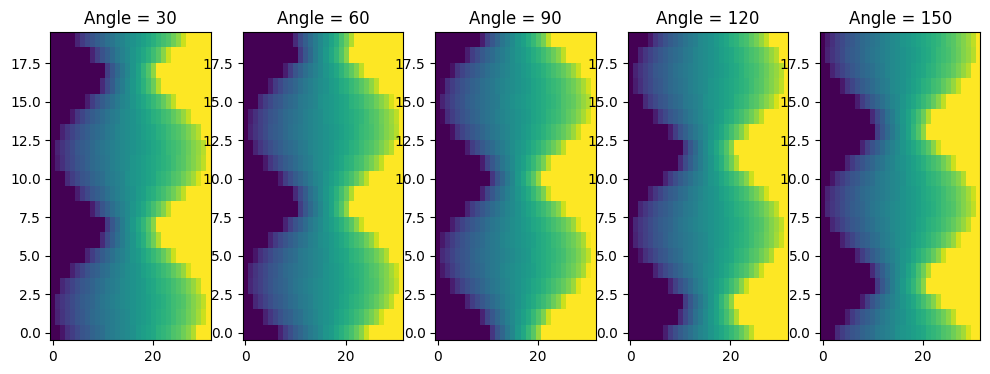

In [92]:
fig, ax = plt.subplots(1, 5, figsize=(12, 4))
ax[0].imshow(ipt_ellipse_30, aspect='auto', origin='lower')
ax[0].set_title('Angle = 30')
ax[1].imshow(ipt_ellipse_60, aspect='auto', origin='lower')
ax[1].set_title('Angle = 60')
ax[2].imshow(ipt_ellipse_90, aspect='auto', origin='lower')
ax[2].set_title('Angle = 90')
ax[3].imshow(ipt_ellipse_120, aspect='auto', origin='lower')
ax[3].set_title('Angle = 120')
ax[4].imshow(ipt_ellipse_150, aspect='auto', origin='lower')
ax[4].set_title('Angle = 150')

plt.show()

## Experimenting with number of directions